# pneumonia 

## normal VS pneumatic person

In [74]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

In [75]:
import os

In [76]:
dataset_path=r"C:\artificial_intelligence_coarse\mydatasetkaggle\archive\chest_xray\train"

In [77]:
class_label=os.listdir(dataset_path)
class_label

['NORMAL', 'PNEUMONIA']

In [78]:
normal_class=os.path.join(dataset_path,class_label[0])

In [79]:
normal_class

'C:\\artificial_intelligence_coarse\\mydatasetkaggle\\archive\\chest_xray\\train\\NORMAL'

In [80]:
normalimage1=os.listdir(normal_class)[0]
normalimage1

'IM-0115-0001.jpeg'

In [81]:
normalimage1path=os.path.join(normal_class,normalimage1)

In [82]:
import matplotlib.pyplot as plt

In [83]:
arr=plt.imread(normalimage1path)

In [84]:
arr.shape

(1858, 2090)

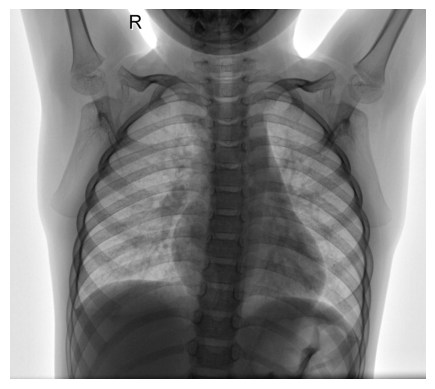

In [85]:
plt.imshow(arr,cmap="gray_r")
plt.axis("OFF")
plt.show()

In [86]:
arr.size

3883220

In [87]:
images=[]
label=[]

for ind,cpath in enumerate(os.listdir(dataset_path)):
    class_path=os.path.join(dataset_path,cpath)
    for img_name in os.listdir(class_path):
        imgpath=os.path.join(class_path,img_name)
        img=plt.imread(imgpath)
        images.append(img)
        label.append(ind)
    print("class 1  normal complete")

class 1  normal complete
class 1  normal complete


In [88]:
images

[array([[ 22,  24,  24, ...,  96,  94,  93],
        [ 23,  24,  24, ...,  97,  94,  92],
        [ 24,  24,  23, ...,  99,  96,  94],
        ...,
        [ 49,  50,  48, ..., 119, 119, 119],
        [ 50,  52,  53, ..., 123, 124, 123],
        [ 52,  53,  54, ..., 129, 128, 127]],
       shape=(1858, 2090), dtype=uint8),
 array([[11, 11, 15, ..., 17, 16, 15],
        [ 9, 10, 14, ..., 17, 15, 13],
        [ 8, 10, 14, ..., 18, 16, 15],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]], shape=(1152, 1422), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 2, 0, 0],
        [0, 0, 0, ..., 3, 2, 2],
        [0, 0, 0, ..., 3, 3, 3]], shape=(1434, 1810), dtype=uint8),
 array([[36, 38, 40, ..., 21, 20, 20],
        [36, 38, 40, ..., 21, 21, 21],
        [37, 38, 39, ..., 22, 21, 20],
        ...,
        [13, 14, 

In [89]:
data=pd.DataFrame({
    "Xray":images,
    "label":label
})

In [90]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5216 entries, 0 to 5215
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Xray    5216 non-null   object
 1   label   5216 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 81.6+ KB


In [91]:
data[data['label']==0]

,Xray,label
0,"[[22, 24, 24, 23, 22, 23, 23, 23, 20, 20, 20, ...",0
1,"[[11, 11, 15, 15, 15, 18, 19, 24, 26, 24, 23, ...",0
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
3,"[[36, 38, 40, 41, 40, 40, 41, 43, 44, 45, 47, ...",0
4,"[[75, 77, 74, 73, 74, 72, 68, 71, 67, 64, 64, ...",0
...,...,...
1336,"[[1, 0, 0, 0, 0, 255, 254, 255, 254, 255, 255,...",0
1337,"[[5, 4, 6, 10, 3, 252, 251, 255, 251, 255, 251...",0
1338,"[[4, 0, 6, 4, 0, 251, 251, 255, 249, 255, 248,...",0
1339,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0


In [92]:
data[data['label']==1]

,Xray,label
1341,"[[19, 19, 18, 18, 18, 19, 20, 20, 21, 24, 28, ...",1
1342,"[[66, 64, 62, 61, 61, 60, 58, 55, 61, 65, 72, ...",1
1343,"[[14, 14, 14, 14, 15, 16, 18, 18, 23, 22, 23, ...",1
1344,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
1345,"[[10, 14, 19, 23, 26, 28, 30, 32, 29, 29, 30, ...",1
...,...,...
5211,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
5212,"[[95, 94, 95, 96, 92, 89, 93, 100, 99, 97, 96,...",1
5213,"[[23, 23, 24, 24, 23, 23, 22, 21, 23, 22, 20, ...",1
5214,"[[32, 31, 30, 28, 28, 29, 30, 31, 37, 35, 33, ...",1


In [93]:
data['Xray'].apply(lambda s:s.shape).value_counts()

Xray
(648, 1072)     7
(728, 1080)     6
(680, 1008)     5
(672, 976)      5
(872, 1216)     5
               ..
(512, 984)      1
(1152, 1432)    1
(1096, 1232)    1
(882, 1414)     1
(728, 1248)     1
Name: count, Length: 4366, dtype: int64

In [94]:
data["Xray"].iloc[0].shape

(1858, 2090)

In [95]:
from PIL import Image

In [96]:
newimage=[]
labeling=[]
for ind,imgres in zip(label,images):
    nimage=Image.fromarray(imgres)
# Convert every image to grayscale
    nimage = nimage.convert("L")

    nimage=nimage.resize((224,224))

    nimage=np.array(nimage)

    newimage.append(nimage)
    labeling.append(ind)


In [97]:
newimage[0].shape

(224, 224)

In [98]:
newimage[0].shape

(224, 224)

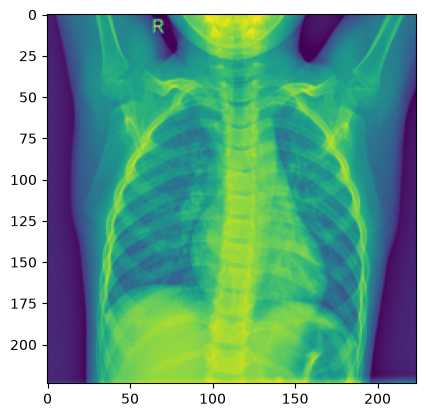

In [99]:
plt.imshow(newimage[0])

In [100]:
df=pd.DataFrame({
    'xray':newimage,
    "Label":labeling})

In [101]:
df

,xray,Label
0,"[[22, 20, 19, 18, 15, 28, 54, 59, 63, 67, 71, ...",0
1,"[[15, 23, 26, 30, 33, 36, 37, 43, 48, 48, 49, ...",0
2,"[[0, 0, 0, 8, 20, 26, 32, 36, 42, 45, 48, 56, ...",0
3,"[[40, 45, 48, 53, 56, 58, 62, 68, 75, 77, 81, ...",0
4,"[[77, 72, 65, 57, 49, 40, 32, 27, 24, 24, 22, ...",0
...,...,...
5211,"[[0, 0, 0, 0, 0, 0, 5, 18, 27, 34, 43, 51, 54,...",1
5212,"[[93, 95, 94, 95, 90, 89, 92, 97, 107, 113, 11...",1
5213,"[[25, 24, 21, 14, 5, 1, 1, 0, 0, 0, 0, 7, 44, ...",1
5214,"[[29, 32, 38, 42, 38, 38, 36, 35, 41, 54, 55, ...",1


In [102]:
df.iloc[0,0]

array([[ 22,  20,  19, ...,  95,  95,  95],
       [ 22,  21,  19, ...,  93,  95,  95],
       [ 23,  21,  19, ...,  94,  94,  93],
       ...,
       [ 29,  29,  27, ...,  59,  60,  60],
       [ 34,  35,  34, ...,  80,  82,  82],
       [ 46,  46,  45, ..., 109, 110, 111]], shape=(224, 224), dtype=uint8)

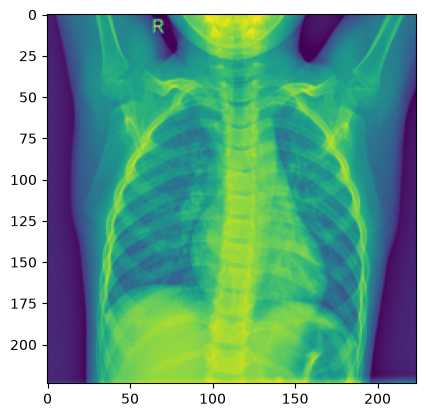

In [103]:
plt.imshow(df.iloc[0,0])

In [113]:
x=df["xray"].values
y=df["Label"].values

In [114]:
x[0].shape

(224, 224)

In [115]:
x=np.array(x)
x.shape

(5216,)

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5216 entries, 0 to 5215
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   xray    5216 non-null   object
 1   Label   5216 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 81.6+ KB


In [117]:
for i, img in enumerate(x):
    if img.shape != (224, 224):
        print(i, img.shape)

In [118]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.1,random_state=1)

In [119]:
model=SVC(C=0.1,kernel="linear")

In [120]:
model.fit(x,y)

ValueError: setting an array element with a sequence.